In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Cari file dataset di Drive
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'Happiness' in file or 'happiness' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Kelas D_Happiness and Satisfaction.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Ganti path sesuai hasil Cell 2
df = pd.read_csv('/content/drive/MyDrive/Kelas D_Happiness and Satisfaction.csv',
                 sep=';', decimal=',')

# Bersihkan kolom Region
df['Region'] = df['Region'].str.replace("'", '').str.strip()

print(df.shape)
print(df.head())

(111, 11)
     Country  adjusted_satisfaction (0-100)  avg_satisfaction (0-10)  \
0    Armenia                             37                      4.9   
1     Angola                             26                      4.3   
2  Argentina                             60                      7.1   
3    Austria                             59                      7.2   
4  Australia                             65                      7.6   

   std_satisfaction  avg_income (&)  median_income (&)  income_inequality  \
0              2.42         2096.76        1731.506667          31.445556   
1              3.19         1448.88        1044.240000          42.720000   
2              1.91         7101.12        5109.400000          45.475556   
3              2.11        19457.04       16879.620000          30.296250   
4              1.80        19917.00       15846.060000          35.285000   

                        Region  Happy Score (0-10)      GDP  country.1  
0   Central and Easte

In [6]:
def wrap_labels(labels, width=22):
    return ['\n'.join(textwrap.wrap(str(l), width)) for l in labels]

def annotate_barh(ax, fmt='{:.1f}', pad=0.3):
    for bar in ax.patches:
        ax.text(
            bar.get_width() + pad,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(bar.get_width()),
            va='center', ha='left', fontsize=7.5
        )

In [7]:
def grafik_A_kelompok1(ax):
    agg = (df.groupby('Region')['adjusted_satisfaction (0-100)']
             .mean()
             .sort_values())
    colors = sns.color_palette('Blues_d', len(agg))
    ax.barh(wrap_labels(agg.index), agg.values, color=colors, edgecolor='white')
    ax.set_title('Rata-rata Kepuasan Hidup\nper Wilayah Regional',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Rata-rata Adjusted Satisfaction (0–100)', fontsize=9)
    annotate_barh(ax, fmt='{:.1f}', pad=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

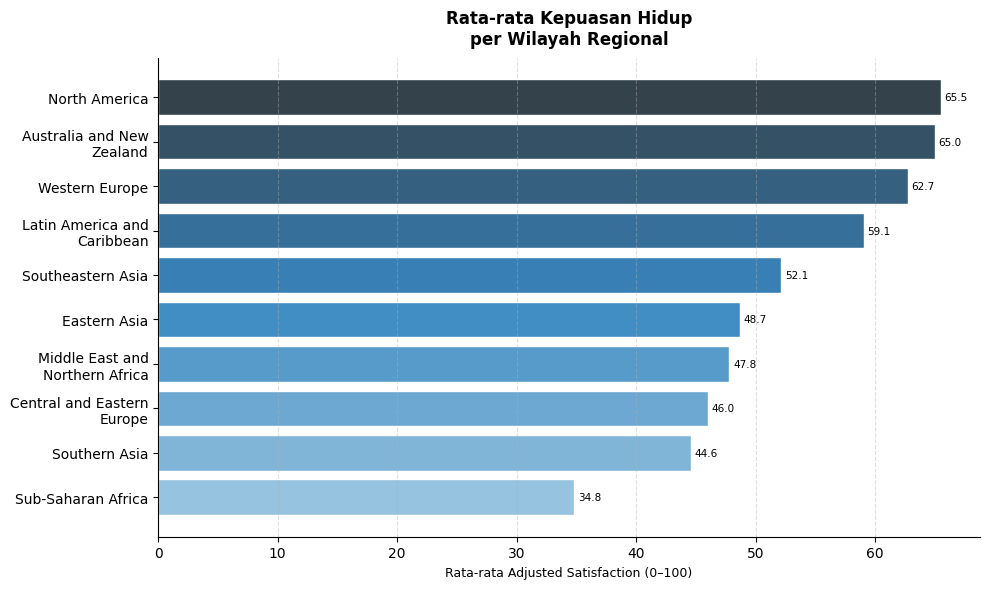

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
grafik_A_kelompok1(ax)   # ganti sesuai kelompokmu
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grafik_A_kelompok1.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

df = pd.read_csv('/content/drive/MyDrive/Kelas D_Happiness and Satisfaction.csv',
                 sep=';', decimal=',')

df['Region'] = df['Region'].str.replace("'", '').str.strip()

print(df.shape)
print(df.head())

(111, 11)
     Country  adjusted_satisfaction (0-100)  avg_satisfaction (0-10)  \
0    Armenia                             37                      4.9   
1     Angola                             26                      4.3   
2  Argentina                             60                      7.1   
3    Austria                             59                      7.2   
4  Australia                             65                      7.6   

   std_satisfaction  avg_income (&)  median_income (&)  income_inequality  \
0              2.42         2096.76        1731.506667          31.445556   
1              3.19         1448.88        1044.240000          42.720000   
2              1.91         7101.12        5109.400000          45.475556   
3              2.11        19457.04       16879.620000          30.296250   
4              1.80        19917.00       15846.060000          35.285000   

                        Region  Happy Score (0-10)      GDP  country.1  
0   Central and Easte

In [12]:
def wrap_labels(labels, width=22):
    return ['\n'.join(textwrap.wrap(str(l), width)) for l in labels]

def annotate_barh(ax, fmt='{:.1f}', pad=0.3):
    for bar in ax.patches:
        ax.text(
            bar.get_width() + pad,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(bar.get_width()),
            va='center', ha='left', fontsize=7.5
        )

In [13]:
def grafik_A_kelompok2(ax):
    agg = (df.groupby('Region')['Happy Score (0-10)']
             .max()
             .sort_values())

    colors = sns.color_palette('Greens_d', len(agg))
    ax.barh(wrap_labels(agg.index), agg.values, color=colors, edgecolor='white')

    ax.set_title('Nilai Maksimum Happy Score (0–10)\nper Wilayah Regional',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Maksimum Happy Score (0–10)', fontsize=9)
    ax.set_ylabel('Region', fontsize=9)
    annotate_barh(ax, fmt='{:.3f}', pad=0.02)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

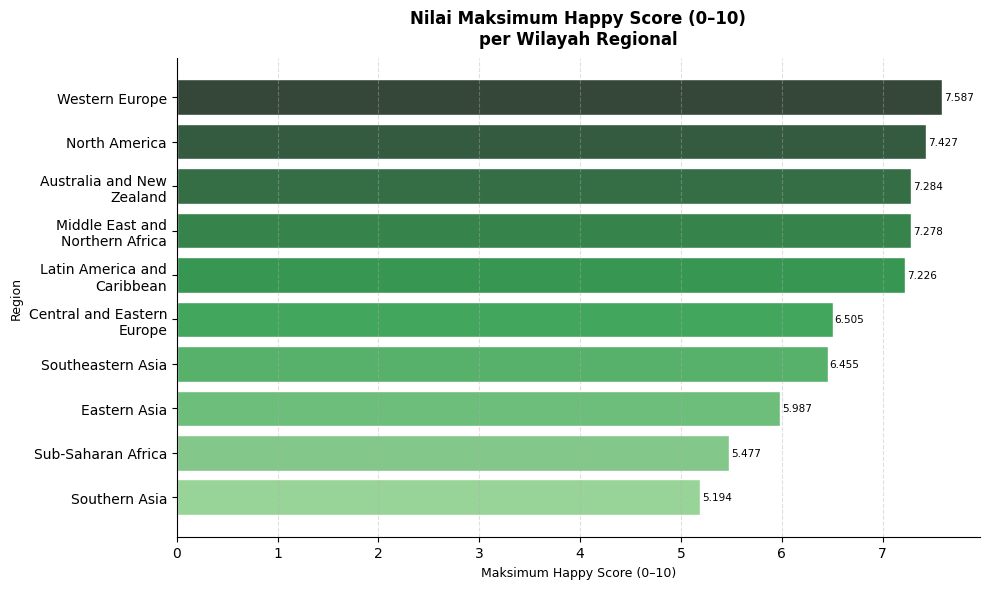

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
grafik_A_kelompok2(ax)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grafik_A_kelompok2.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [15]:
def grafik_A_kelompok3(ax):
    agg = (df.groupby('Region')['Country']
             .count()
             .sort_values(ascending=False))

    colors = sns.color_palette('Set2', len(agg))
    ax.pie(
        agg.values,
        labels=wrap_labels(agg.index, width=18),
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.6, edgecolor='white', linewidth=1.5),
        textprops={'fontsize': 7.5}
    )
    ax.set_title('Jumlah Negara Peserta Survei\nper Wilayah Regional',
                 fontsize=12, fontweight='bold', pad=10)

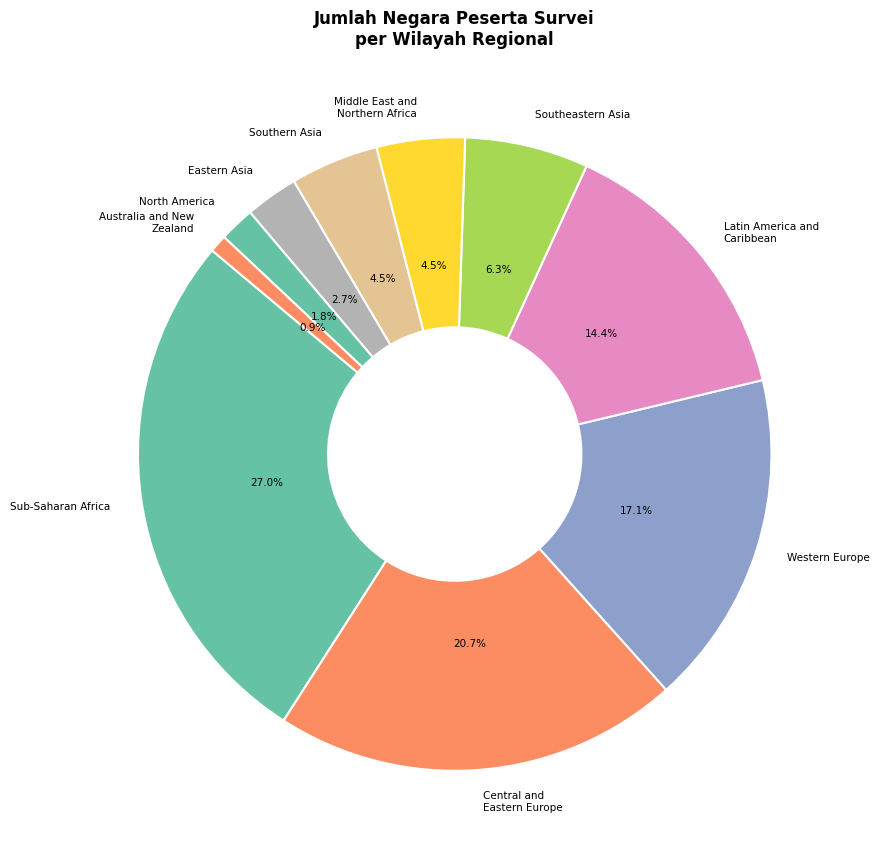

In [16]:
fig, ax = plt.subplots(figsize=(9, 9))
grafik_A_kelompok3(ax)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grafik_A_kelompok3.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
def grafik_A_kelompok4(ax):
    agg = (df.groupby('Region')['income_inequality']
             .median()
             .sort_values())

    colors = sns.color_palette('Oranges_d', len(agg))
    ax.barh(wrap_labels(agg.index), agg.values, color=colors, edgecolor='white')

    ax.set_title('Median Income Inequality\nper Wilayah Regional',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Median Income Inequality', fontsize=9)
    ax.set_ylabel('Region', fontsize=9)
    annotate_barh(ax, fmt='{:.2f}', pad=0.1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

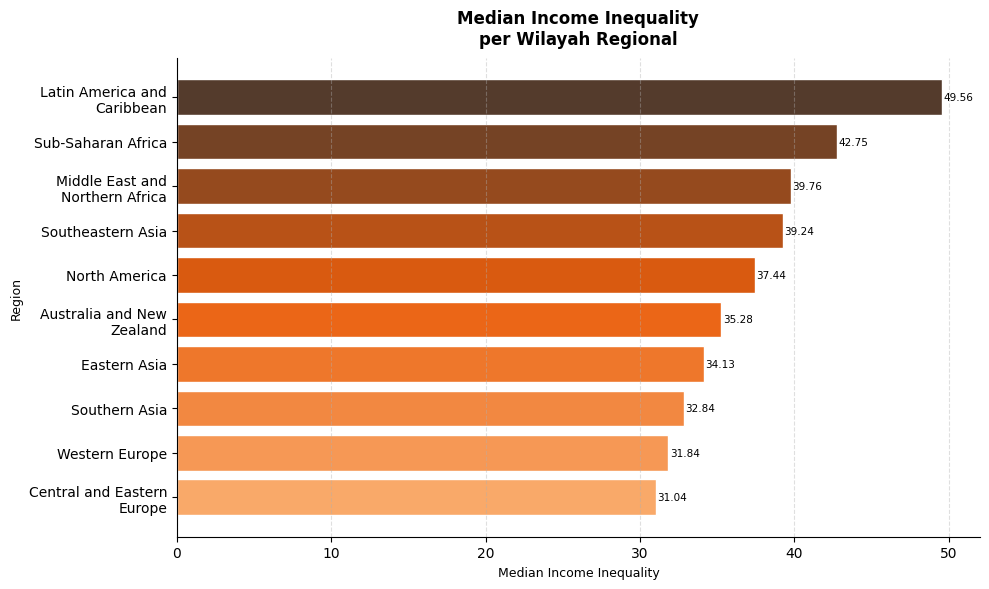

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
grafik_A_kelompok4(ax)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grafik_A_kelompok4.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:
def grafik_A_kelompok5(ax):
    agg = (df.groupby('Region')['avg_income (&)']
             .mean()
             .sort_values())

    colors = sns.color_palette('Purples_d', len(agg))
    ax.barh(wrap_labels(agg.index), agg.values, color=colors, edgecolor='white')

    ax.set_title('Rata-rata Pendapatan (avg_income)\nper Kawasan Region',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Rata-rata avg_income (&)', fontsize=9)
    ax.set_ylabel('Region', fontsize=9)
    annotate_barh(ax, fmt='{:,.0f}', pad=50)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

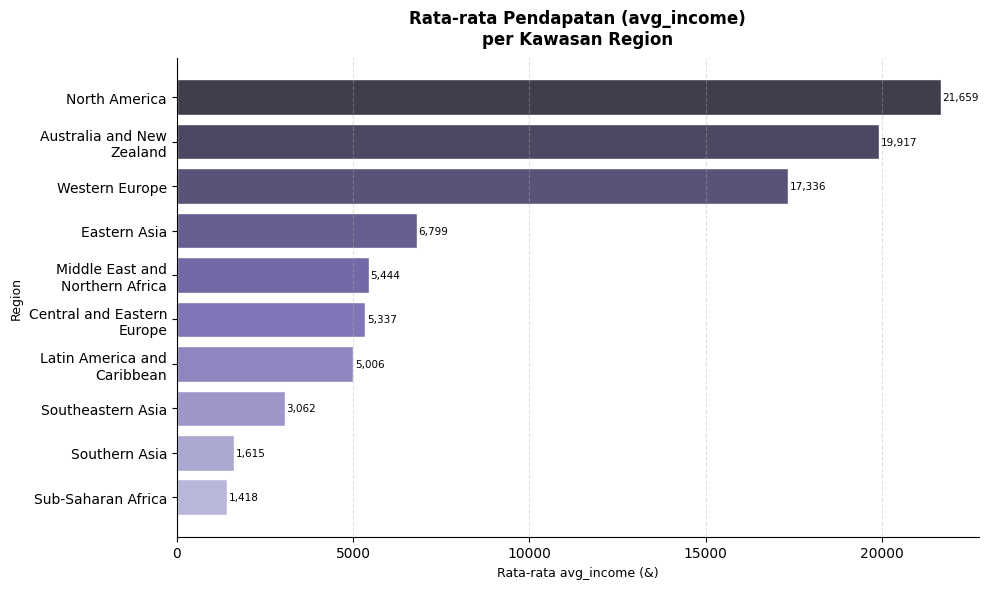

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
grafik_A_kelompok5(ax)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grafik_A_kelompok5.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [21]:
def grafik_A_kelompok6(ax):
    agg = (df.groupby('Region')['income_inequality']
             .agg(['min', 'max'])
             .sort_values('max')
             .rename(columns={'min': 'Minimum', 'max': 'Maksimum'}))

    labels = wrap_labels(agg.index)
    x = range(len(agg))
    w = 0.35

    b_min = ax.barh([i - w/2 for i in x], agg['Minimum'],
                    height=w, label='Minimum', color='#4e9af1', edgecolor='white')
    b_max = ax.barh([i + w/2 for i in x], agg['Maksimum'],
                    height=w, label='Maksimum', color='#f1774e', edgecolor='white')

    ax.set_yticks(list(x))
    ax.set_yticklabels(labels, fontsize=7.5)
    ax.set_title('Nilai Min & Maks Income Inequality\nper Wilayah Region',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Income Inequality', fontsize=9)
    ax.legend(fontsize=8)

    for b in list(b_min) + list(b_max):
        ax.text(b.get_width() + 0.2, b.get_y() + b.get_height() / 2,
                f'{b.get_width():.2f}', va='center', ha='left', fontsize=6.5)

    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

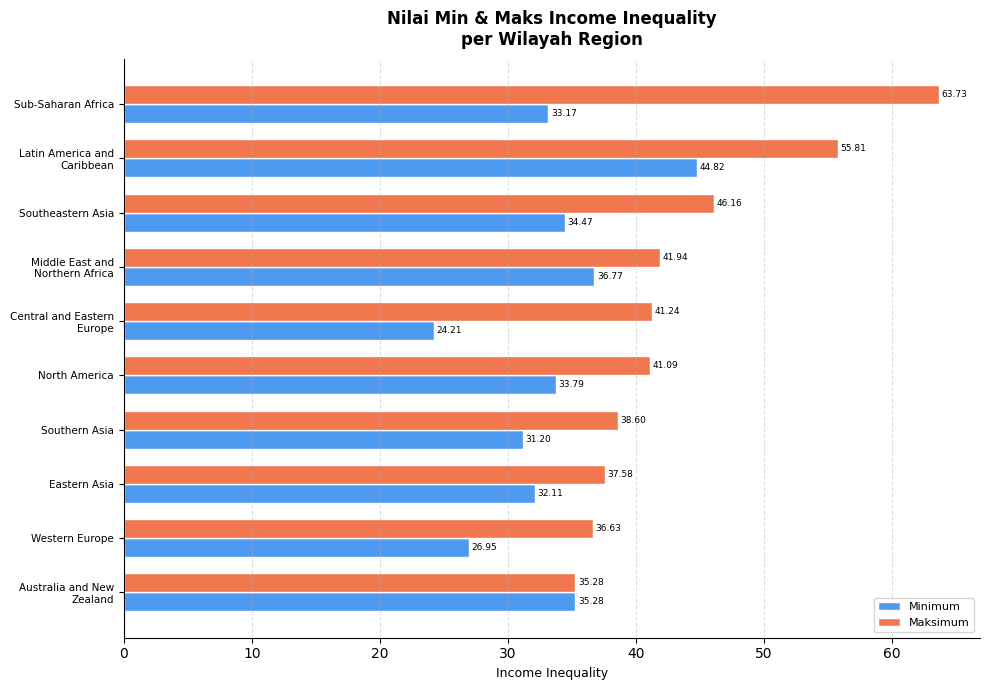

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
grafik_A_kelompok6(ax)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grafik_A_kelompok6.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [23]:
def grafik_A_kelompok7(ax):
    agg = (df.groupby('Region')['Happy Score (0-10)']
             .std()
             .dropna()
             .sort_values())

    colors = sns.color_palette('Reds_d', len(agg))
    ax.barh(wrap_labels(agg.index), agg.values, color=colors, edgecolor='white')

    ax.set_title('Standar Deviasi Happy Score (0–10)\nper Wilayah Region',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Standar Deviasi', fontsize=9)
    ax.set_ylabel('Region', fontsize=9)
    annotate_barh(ax, fmt='{:.3f}', pad=0.005)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

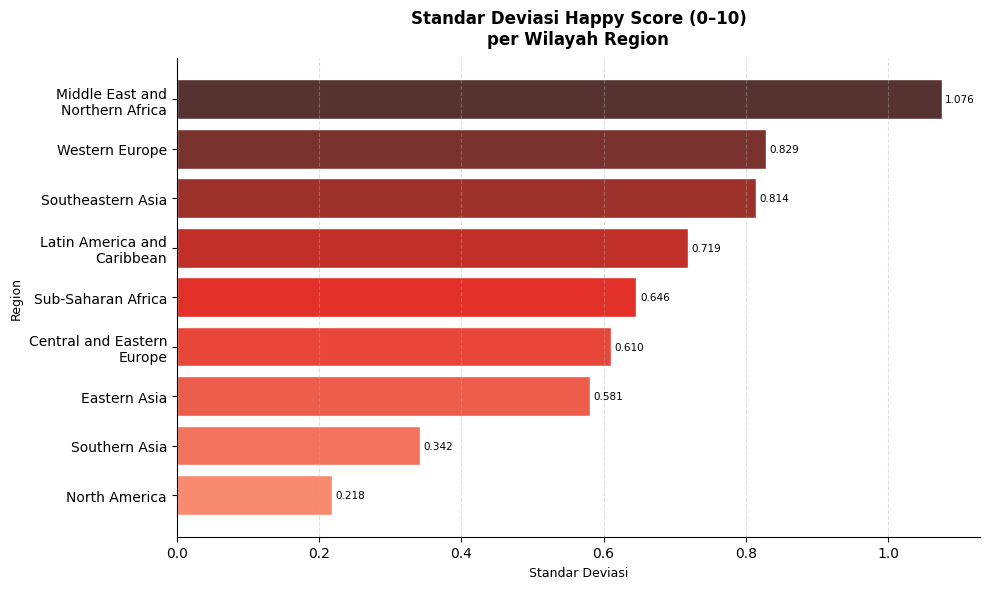

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
grafik_A_kelompok7(ax)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/grafik_A_kelompok7.png',
            dpi=150, bbox_inches='tight')
plt.show()